# Analisis Data Netflix
Analisis eksploratif terhadap dataset Netflix Movies and TV Shows untuk menemukan tren konten, distribusi genre, negara produksi, dan rating.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [3]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


(8807, 12)

In [6]:
# cek missing values
df.isnull().sum()

# cek duplikat
df.duplicated().sum()

np.int64(0)

In [12]:
# Isi kolom kategorikal yang banyak kosong dengan 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Kolom yang missing-nya sedikit, aman untuk di-drop barisnya
df = df.dropna(subset=['date_added', 'rating', 'duration'])

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [14]:
# Convert date_added ke datetime
if df['date_added'].dtype == 'object':
    df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
else:
    df['date_added'] = pd.to_datetime(df['date_added'])

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

df[['date_added', 'year_added', 'month_added']].head()

,date_added,year_added,month_added
0,2021-09-25,2021,September
1,2021-09-24,2021,September
2,2021-09-24,2021,September
3,2021-09-24,2021,September
4,2021-09-24,2021,September


In [16]:
# Untuk Movie -> durasi dalam menit
df['duration_minutes'] = df[df['type'] == 'Movie']['duration'].str.replace(' min', '').astype(float)

# Untuk TV Show -> jumlah season
df['duration_seasons'] = df[df['type'] == 'TV Show']['duration'].str.extract(r'(\d+)').astype(float)

In [17]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8790 non-null   object        
 1   type              8790 non-null   object        
 2   title             8790 non-null   object        
 3   director          8790 non-null   object        
 4   cast              8790 non-null   object        
 5   country           8790 non-null   object        
 6   date_added        8790 non-null   datetime64[ns]
 7   release_year      8790 non-null   int64         
 8   rating            8790 non-null   object        
 9   duration          8790 non-null   object        
 10  listed_in         8790 non-null   object        
 11  description       8790 non-null   object        
 12  year_added        8790 non-null   int32         
 13  month_added       8790 non-null   object        
 14  duration_minutes  6126 non-nu

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_minutes,duration_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,90.0,NaN
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September,NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September,NaN,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September,NaN,2.0


## Exploratory Data Analysis (EDA)

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

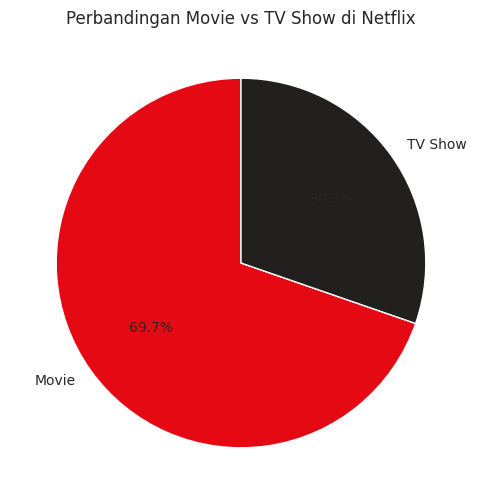

In [26]:
#Insight 1: Perbandingan Movie vs TV Show
plt.figure(figsize=(6,6))
df['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#E50914','#221f1f'], startangle=90)
plt.title('Perbandingan Movie vs TV Show di Netflix')
plt.ylabel('')
plt.show()

Disini dapat kita lihat bahwa Movie mendominasi katalog Netflix dengan porsi 69,7%

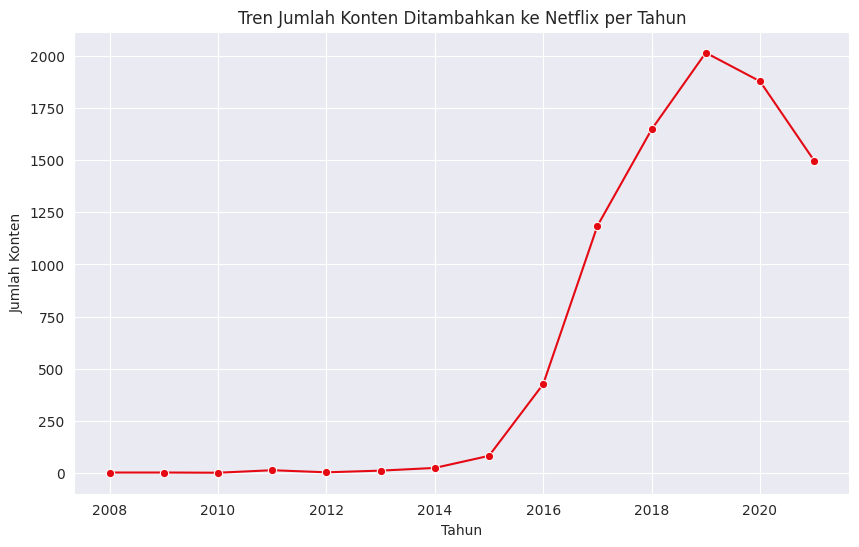

In [27]:
#Insight 2: Tren Konten Ditambahkan per Tahun
yearly = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,6))
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', color='#E50914')
plt.title('Tren Jumlah Konten Ditambahkan ke Netflix per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Konten')
plt.show()

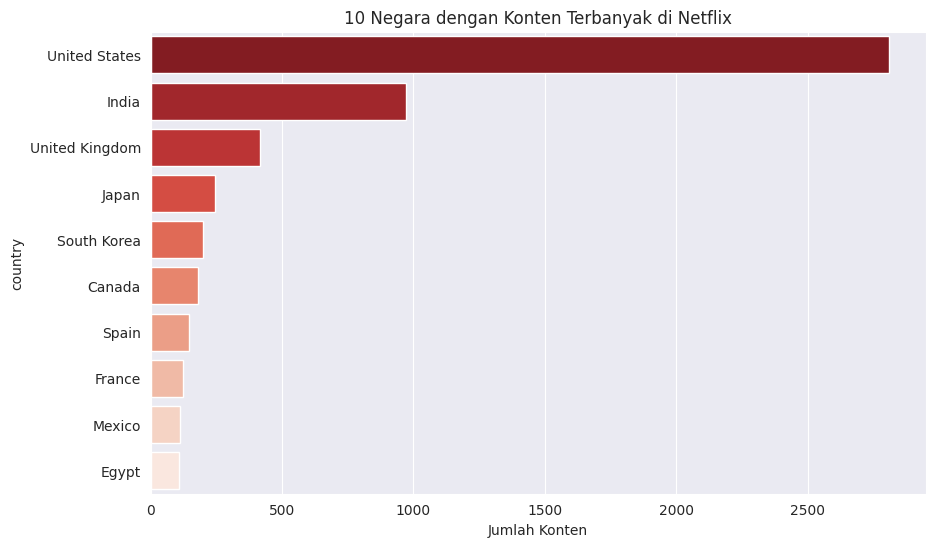

In [29]:
# Insight 3: Top 10 Negara Produksi Konten
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='Reds_r', legend=False)
plt.title('10 Negara dengan Konten Terbanyak di Netflix')
plt.xlabel('Jumlah Konten')
plt.show()

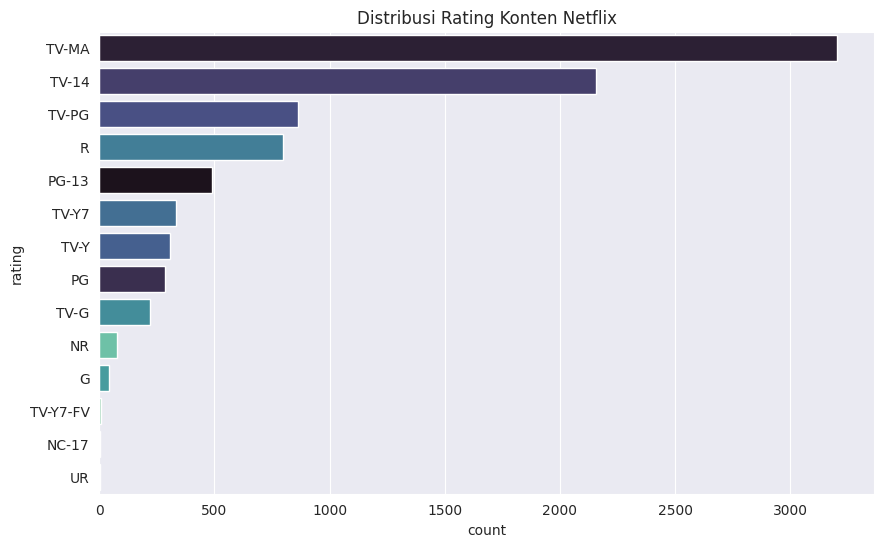

In [33]:
#Insight 4: Distribusi Rating Konten
plt.figure(figsize=(10,6))
order = df['rating'].value_counts().index
sns.countplot(data=df, y='rating', order=order, hue='rating', palette='mako', legend=False)
plt.title('Distribusi Rating Konten Netflix')
plt.show()

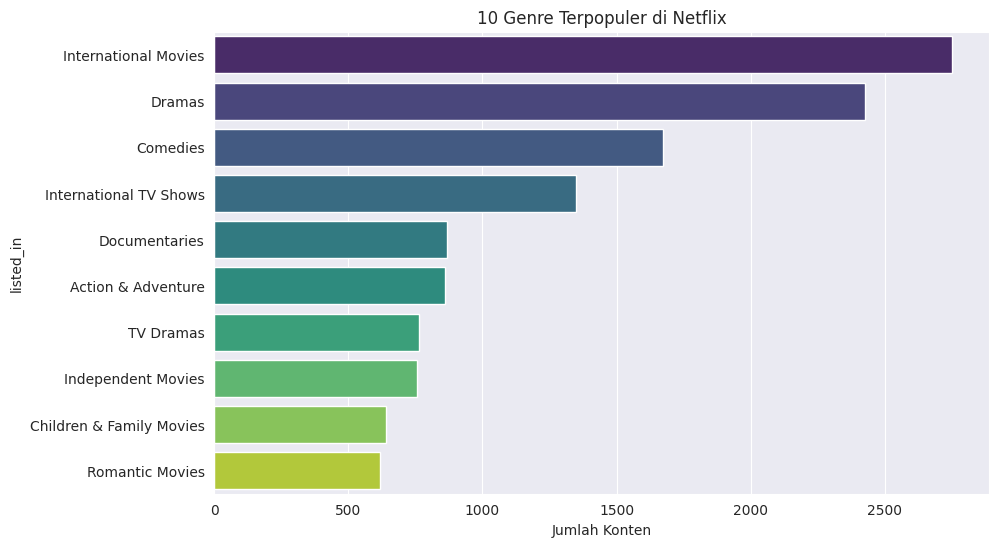

In [32]:
#Insight 5: Genre Terpopuler
from collections import Counter

genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='viridis', legend=False)
plt.title('10 Genre Terpopuler di Netflix')
plt.xlabel('Jumlah Konten')
plt.show()

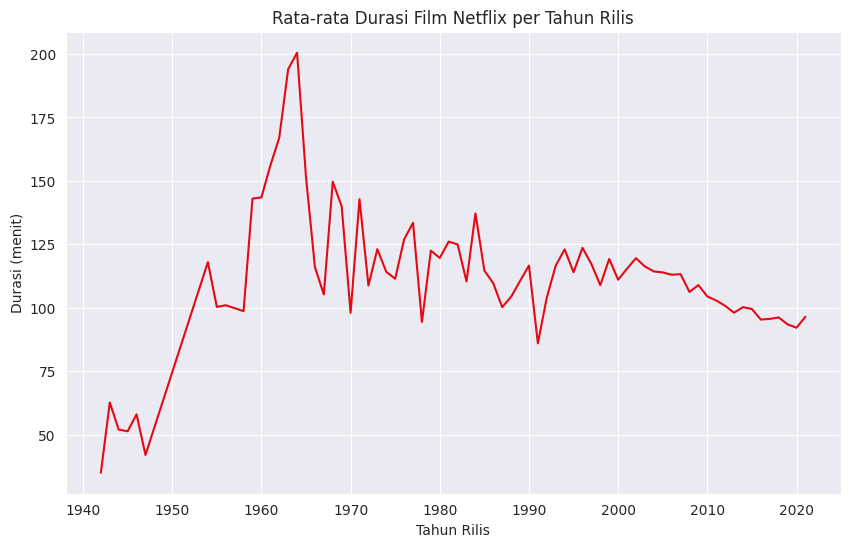

In [34]:
#Insight 6: Durasi Rata-rata Film per Tahun
movie_duration = df[df['type']=='Movie'].groupby('release_year')['duration_minutes'].mean()

plt.figure(figsize=(10,6))
sns.lineplot(x=movie_duration.index, y=movie_duration.values, color='#E50914')
plt.title('Rata-rata Durasi Film Netflix per Tahun Rilis')
plt.xlabel('Tahun Rilis')
plt.ylabel('Durasi (menit)')
plt.show()

## Kesimpulan

Berdasarkan analisis terhadap dataset Netflix Movies and TV Shows, ditemukan beberapa insight utama:

1. **Komposisi konten**: Movie mendominasi katalog Netflix dibanding TV Show.
2. **Tren pertumbuhan**: Jumlah konten yang ditambahkan meningkat pesat pada periode tertentu, khususnya menjelang 2019-2020.
3. **Negara produksi**: Amerika Serikat menjadi kontributor konten terbesar, diikuti oleh India dan Inggris.
4. **Rating dominan**: TV-MA merupakan rating paling umum, menunjukkan Netflix banyak menyasar audiens dewasa.
5. **Genre populer**: Drama Internasional dan Komedi menjadi genre yang paling sering muncul.
6. **Durasi film**: Rata-rata durasi film Netflix menunjukkan tren menurun sejak tahun 2000-an, dari sekitar 120 menit menjadi sekitar 95 menit pada 2021. Fluktuasi ekstrem pada periode sebelum 1970 kemungkinan disebabkan oleh jumlah data film lama yang sangat sedikit di katalog, sehingga kurang representatif. Tren penurunan durasi di era modern dapat mengindikasikan preferensi Netflix terhadap format film yang lebih ringkas, sejalan dengan kebiasaan menonton penonton digital saat ini.

### Rekomendasi
- Jika ingin ekspansi pasar, Netflix bisa mempertimbangkan menambah konten di negara-negara dengan produksi rendah namun berpotensi tinggi.
- Diversifikasi genre bisa membantu menjangkau audiens yang lebih luas.